In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib gensim


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Bidirectional, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from gensim.models import Word2Vec
print('TF version:', tf.__version__)

TF version: 2.20.0


In [3]:
# Hyperparameters
MAX_VOCAB  = 20000
MAX_LEN    = 200
EMBED_DIM  = 100   # must match Word2Vec vector_size
BATCH_SIZE = 128
EPOCHS     = 10

In [4]:
# Load dataset and clean raw review text
def clean(text):
    text = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text = text.lower()                         # lowercase
    text = re.sub(r'[^a-z\s]', '', text)       # remove punctuation and digits
    text = re.sub(r'\s+', ' ', text).strip()   # normalize whitespace
    return text

cwd = os.getcwd()
data_path = os.path.abspath(os.path.join(cwd, '..', 'MLP_folder', 'IMDB_Dataset.csv'))
df = pd.read_csv(data_path)
df['review'] = df['review'].apply(clean)
y = df['sentiment'].map({'positive': 1, 'negative': 0}).values
texts = df['review'].values
print(f'Loaded {len(df)} reviews')
df.head()

Loaded 50000 reviews


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


In [5]:
# Split data into train/val/test (70/10/20)
X_train_t, X_test_t, y_train, y_test = train_test_split(
    texts, y, test_size=0.2, random_state=42, stratify=y
)
X_train_t, X_val_t, y_train, y_val = train_test_split(
    X_train_t, y_train, test_size=0.125, random_state=42, stratify=y_train
)  # 0.125 x 0.8 = 0.1 of total
print(f'Train: {len(X_train_t)}, Val: {len(X_val_t)}, Test: {len(X_test_t)}')

Train: 35000, Val: 5000, Test: 10000


In [6]:
# Train Word2Vec on training corpus to obtain pretrained word embeddings
train_sentences = [text.split() for text in X_train_t]
print(f'Training Word2Vec on {len(train_sentences)} sentences...')
w2v = Word2Vec(
    sentences=train_sentences,
    vector_size=EMBED_DIM,
    window=5,
    min_count=2,
    workers=4,
    epochs=10
)
print(f'Word2Vec vocabulary size: {len(w2v.wv)}')

Training Word2Vec on 35000 sentences...
Word2Vec vocabulary size: 62663


In [7]:
# Tokenize vocabulary and pad sequences to fixed length
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_t)

X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_t), maxlen=MAX_LEN, padding='post', truncating='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val_t),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_t),  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (35000, 200), Val: (5000, 200), Test: (10000, 200)


In [8]:
# Build embedding matrix by mapping tokenizer word indices to Word2Vec vectors
embedding_matrix = np.zeros((MAX_VOCAB + 1, EMBED_DIM))
hits = 0
for word, idx in tokenizer.word_index.items():
    if idx <= MAX_VOCAB and word in w2v.wv:
        embedding_matrix[idx] = w2v.wv[word]
        hits += 1
print(f'Embedding matrix shape: {embedding_matrix.shape}')
print(f'Words found in Word2Vec: {hits} / {min(MAX_VOCAB, len(tokenizer.word_index))}')

Embedding matrix shape: (20001, 100)
Words found in Word2Vec: 19999 / 20000


In [10]:
# Define Bidirectional GRU model with pretrained Word2Vec embedding layer
model = Sequential([
    Embedding(
        MAX_VOCAB + 1, EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False        # freeze pretrained weights
    ),
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 100)       │     2,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200, 128)       │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,099,173 (8.01 MB)

 Trainable params: 99,073 (387.00 KB)

 Non-trainable params: 2,000,100 (7.63 MB)

In [11]:
# Train with early stopping and learning rate reduction on plateau
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 202s 709ms/step - accuracy: 0.7059 - loss: 0.5490 - val_accuracy: 0.8546 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 192s 702ms/step - accuracy: 0.8537 - loss: 0.3438 - val_accuracy: 0.8772 - val_loss: 0.2849 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 189s 691ms/step - accuracy: 0.8775 - loss: 0.2901 - val_accuracy: 0.8890 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 189s 691ms/step - accuracy: 0.8920 - loss: 0.2635 - val_accuracy: 0.8918 - val_loss: 0.2600 - learning_rate: 0.0010
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 188s 687ms/step - accuracy: 0.9009 - loss: 0.2434 - val_accuracy: 0.8930 - val_loss: 0.2607 - learning_rate: 0.0010
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.9158 - loss: 0.2124
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 186s 679ms/step - accuracy:

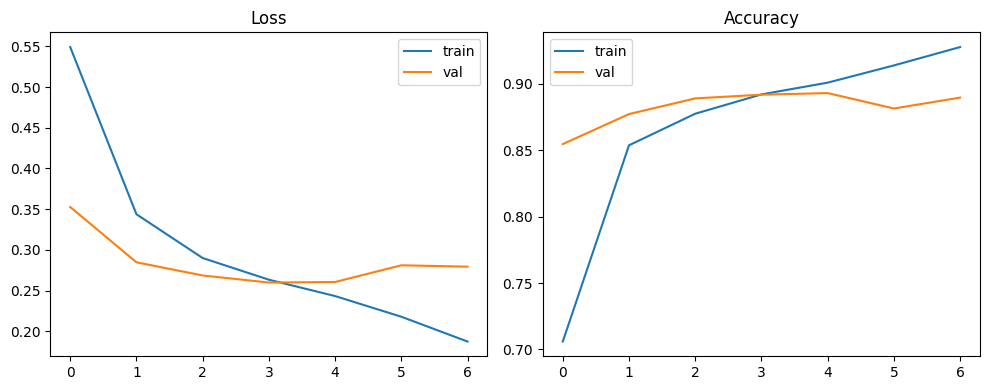

40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step
Accuracy: 0.8855
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      5000
           1       0.87      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Evaluation images saved to c:\Users\HP\Desktop\AAAAAAAAAAAAAAAA\IMDB-Sentiment-Analysis-AMINE\model4_gru_word2vec\results


In [12]:
# Evaluate model and save training curves, confusion matrix, classification report
cwd = os.getcwd()
results_dir = os.path.join(cwd, 'results')
os.makedirs(results_dir, exist_ok=True)

# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'training_curves.png'), dpi=150)
plt.show()

# Predictions
y_pred = (model.predict(X_test, batch_size=256) >= 0.5).astype(int).flatten()
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - BiGRU + Word2Vec')
plt.xlabel('Predicted'); plt.ylabel('Actual')
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'), dpi=150)
plt.close()

# Classification report
report = classification_report(y_test, y_pred, output_dict=True)
labels_order = ['0', '1', 'macro avg', 'weighted avg']
metrics = ['precision', 'recall', 'f1-score']
report_matrix = np.array([[report[l][m] for m in metrics] for l in labels_order if l in report], dtype=np.float32)
row_labels = [l for l in labels_order if l in report]
plt.figure(figsize=(6, 3.5))
plt.imshow(report_matrix, cmap='Greens', aspect='auto')
plt.title('Classification Report - BiGRU + Word2Vec')
plt.xticks(range(len(metrics)), metrics)
plt.yticks(range(len(row_labels)), row_labels)
for (i, j), v in np.ndenumerate(report_matrix):
    plt.text(j, i, f'{v:.2f}', ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'classification_report.png'), dpi=150)
plt.close()
print(f'Evaluation images saved to {results_dir}')

In [13]:
# Save model, tokenizer, and Word2Vec to results folder
model.save(os.path.join(results_dir, 'gru_word2vec_model.keras'))
with open(os.path.join(results_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump({'tokenizer': tokenizer, 'max_len': MAX_LEN, 'max_vocab': MAX_VOCAB}, f)
w2v.save(os.path.join(results_dir, 'word2vec.model'))
print(f'Model saved to {results_dir}')

Model saved to c:\Users\HP\Desktop\AAAAAAAAAAAAAAAA\IMDB-Sentiment-Analysis-AMINE\model4_gru_word2vec\results
